In [4]:
# Wing geometry and Reynolds number calculator

# Fixed design inputs
b = 15.0                 # Wingspan, m
AR = 20.0                # Aspect ratio
V = 22.0                 # Flight speed, m/s
nu = 1.5111e-5           # Kinematic viscosity, m^2/s

# User input
lambda_ratio = float(input("Enter taper ratio lambda = ct/cr: "))

# Validation
if lambda_ratio <= 0 or lambda_ratio > 1:
    raise ValueError("Taper ratio must be between 0 and 1.")

# Wing area
S = b**2 / AR

# Root and tip chords
cr = 2 * S / (b * (1 + lambda_ratio))
ct = lambda_ratio * cr

# Reynolds numbers
Re_root = V * cr / nu
Re_tip = V * ct / nu

# Mean aerodynamic chord
MAC = (2 / 3) * cr * ((1 + lambda_ratio + lambda_ratio**2) / (1 + lambda_ratio))
Re_MAC = V * MAC / nu

# Output
print("\n----- RESULTS -----")
print(f"Wing area, S          = {S:.4f} m^2")
print(f"Taper ratio, lambda   = {lambda_ratio:.4f}")
print(f"Root chord, cr        = {cr:.4f} m")
print(f"Tip chord, ct         = {ct:.4f} m")
print(f"Mean aerodynamic chord= {MAC:.4f} m")
print(f"Root Reynolds number  = {Re_root:.4e}")
print(f"Tip Reynolds number   = {Re_tip:.4e}")
print(f"MAC Reynolds number   = {Re_MAC:.4e}")


----- RESULTS -----
Wing area, S          = 11.2500 m^2
Taper ratio, lambda   = 0.8000
Root chord, cr        = 0.8333 m
Tip chord, ct         = 0.6667 m
Mean aerodynamic chord= 0.7531 m
Root Reynolds number  = 1.2132e+06
Tip Reynolds number   = 9.7060e+05
MAC Reynolds number   = 1.0964e+06


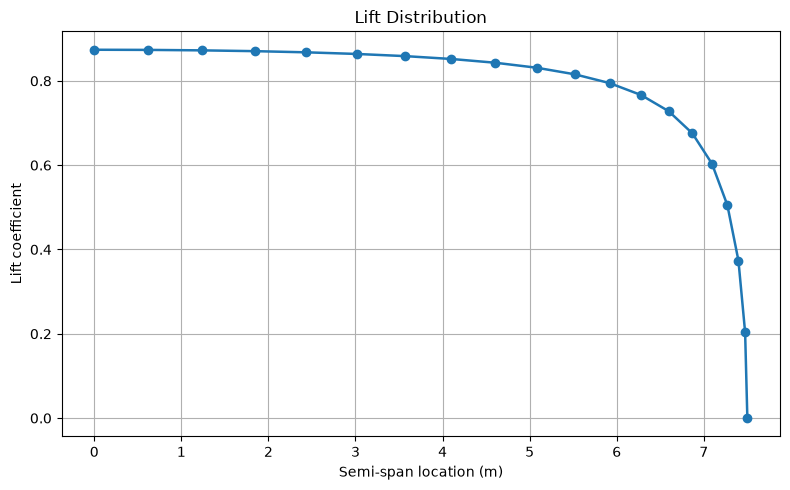

Wing span, b             = 15.000000 m
Mean chord, MAC          = 0.750000 m
Root chord, Croot        = 0.750000 m
Wing lift coefficient    = 0.813887
Lift at 22.00 m/s       = 2714.362447 N
Equivalent supported mass = 276.693420 kg


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Clear previous plots
plt.close("all")

# ====================== INPUTS ======================

N = 19                   # Number of segments - 1
S = 11.25               # Wing area, m^2
AR = 20                 # Aspect ratio
lambda_ratio = 1.0      # Taper ratio
alpha_twist = 0.0       # Twist angle, deg
i_w = 3.35               # Wing setting angle, deg
a_2d = 0.111*57.3          # 2D lift-curve slope, 1/rad
alpha_0 = -4.97         # Zero-lift angle of attack, deg

rho = 1.225             # Air density, kg/m^3
V = 22                  # Airspeed, m/s
g = 9.81                # Gravitational acceleration, m/s^2

# ====================== WING GEOMETRY ======================

b = np.sqrt(AR * S)     # Wing span, m
MAC = S / b             # Mean chord used in the original MATLAB code, m

Croot = (
    1.5 * (1 + lambda_ratio) * MAC
    / (1 + lambda_ratio + lambda_ratio**2)
)                       # Root chord, m

# MATLAB:
# theta = pi/(2*N):pi/(2*N):pi/2
theta = np.arange(1, N + 1) * np.pi / (2 * N)

# MATLAB:
# alpha = i_w + alpha_twist : -alpha_twist/(N-1) : i_w
alpha = np.linspace(i_w + alpha_twist, i_w, N)

# Semi-span locations
z = (b / 2) * np.cos(theta)

# Local chord at each segment
c = Croot * (
    1 - (1 - lambda_ratio) * np.cos(theta)
)

# Lifting-line parameter
mu = c * a_2d / (4 * b)

# Left-hand side of lifting-line equations
LHS = mu * (alpha - alpha_0) / 57.3

# ====================== SOLVE FOR FOURIER COEFFICIENTS ======================

B = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        harmonic = 2 * (j + 1) - 1

        B[i, j] = (
            np.sin(harmonic * theta[i])
            * (
                1
                + (
                    mu[i] * harmonic
                    / np.sin(theta[i])
                )
            )
        )

# Equivalent to MATLAB: A = B \ transpose(LHS)
A = np.linalg.solve(B, LHS)

# ====================== LIFT DISTRIBUTION ======================

sum1 = np.zeros(N)
sum2 = np.zeros(N)

for i in range(N):
    for j in range(N):
        harmonic = 2 * (j + 1) - 1

        sum1[i] += (
            harmonic
            * A[j]
            * np.sin(harmonic * theta[i])
        )

        sum2[i] += (
            A[j]
            * np.sin(harmonic * theta[i])
        )

# Local section lift coefficient
CL = 4 * b * sum2 / c

# Add zero lift coefficient at the wing tip
CL1 = np.concatenate(([0.0], CL))

# Add the wing-tip location to the semi-span coordinates
y_s = np.concatenate(([b / 2], z))

# ====================== PLOT ======================

plt.figure(figsize=(8, 5))

plt.plot(
    y_s,
    CL1,
    "-o",
    linewidth=1.8,
    markersize=6
)

plt.grid(True)
plt.title("Lift Distribution")
plt.xlabel("Semi-span location (m)")
plt.ylabel("Lift coefficient")
plt.tight_layout()
plt.show()

# ====================== WING LIFT ======================

CL_wing = np.pi * AR * A[0]

Lift = 0.5 * rho * V**2 * S * CL_wing

weight = Lift / g

# ====================== OUTPUTS ======================

print(f"Wing span, b             = {b:.6f} m")
print(f"Mean chord, MAC          = {MAC:.6f} m")
print(f"Root chord, Croot        = {Croot:.6f} m")
print(f"Wing lift coefficient    = {CL_wing:.6f}")
print(f"Lift at {V:.2f} m/s       = {Lift:.6f} N")
print(f"Equivalent supported mass = {weight:.6f} kg")

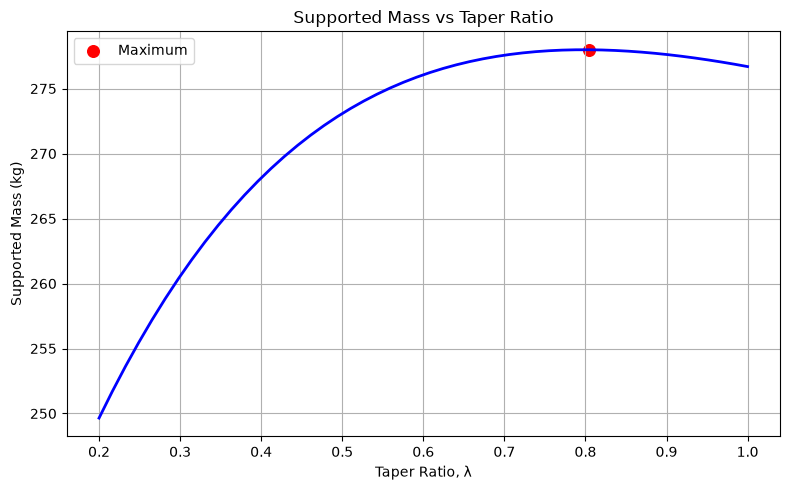

Maximum supported mass = 277.988 kg
Optimum taper ratio    = 0.804


In [6]:
# ====================== MASS vs TAPER RATIO ======================

lambda_values = np.linspace(0.2, 1.0, 50)   # Taper ratio range
mass_values = []

for lambda_ratio in lambda_values:

    # Wing geometry
    Croot = (
        1.5 * (1 + lambda_ratio) * MAC
        / (1 + lambda_ratio + lambda_ratio**2)
    )

    c = Croot * (
        1 - (1 - lambda_ratio) * np.cos(theta)
    )

    mu = c * a_2d / (4 * b)

    LHS = mu * (alpha - alpha_0) / 57.3

    # Build coefficient matrix
    B = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            harmonic = 2 * (j + 1) - 1

            B[i, j] = (
                np.sin(harmonic * theta[i])
                * (
                    1
                    + (
                        mu[i] * harmonic
                        / np.sin(theta[i])
                    )
                )
            )

    # Solve lifting-line equations
    A = np.linalg.solve(B, LHS)

    # Wing lift coefficient
    CL_wing = np.pi * AR * A[0]

    # Lift
    Lift = 0.5 * rho * V**2 * S * CL_wing

    # Equivalent supported mass
    mass = Lift / g

    mass_values.append(mass)

# Convert to numpy array
mass_values = np.array(mass_values)

# ====================== PLOT ======================

plt.figure(figsize=(8,5))
plt.plot(lambda_values, mass_values,
         color='blue',
         linewidth=2)

plt.scatter(lambda_values[np.argmax(mass_values)],
            np.max(mass_values),
            color='red',
            s=70,
            label='Maximum')

plt.grid(True)
plt.xlabel("Taper Ratio, λ")
plt.ylabel("Supported Mass (kg)")
plt.title("Supported Mass vs Taper Ratio")
plt.legend()
plt.tight_layout()
plt.show()

# ====================== RESULTS ======================

best_index = np.argmax(mass_values)

print(f"Maximum supported mass = {mass_values[best_index]:.3f} kg")
print(f"Optimum taper ratio    = {lambda_values[best_index]:.3f}")